In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train_pd = pd.read_csv("train.csv")
test_pd = pd.read_csv("test.csv")

train_pd.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
survived = train_pd["Survived"]
train_pd = train_pd.drop(["Survived"], axis = 1)
display(train_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
train_idx = train_pd["PassengerId"]
test_idx = test_pd["PassengerId"]

combind_pd = pd.concat([train_pd, test_pd]).reset_index(drop = True)

display(combind_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [5]:
print("NULL VALUES:")
print(combind_pd.isnull().sum())

NULL VALUES:
PassengerId       0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64


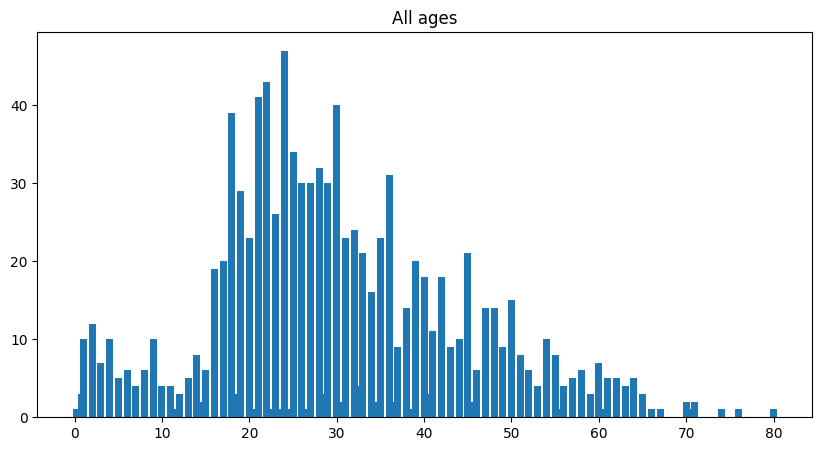

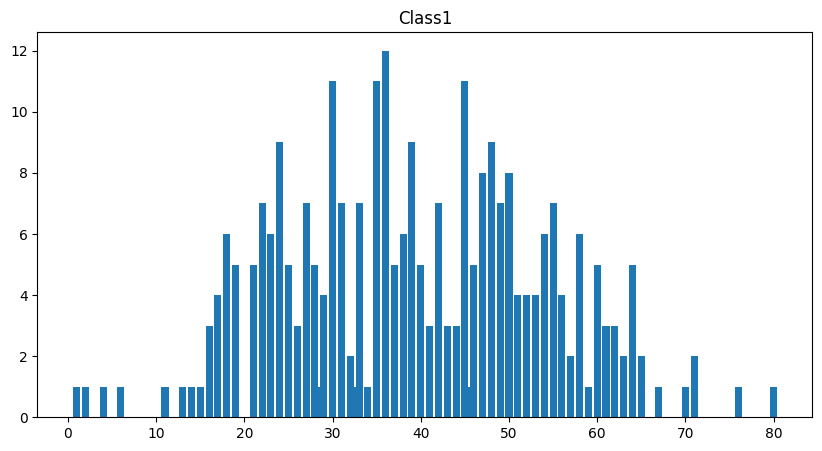

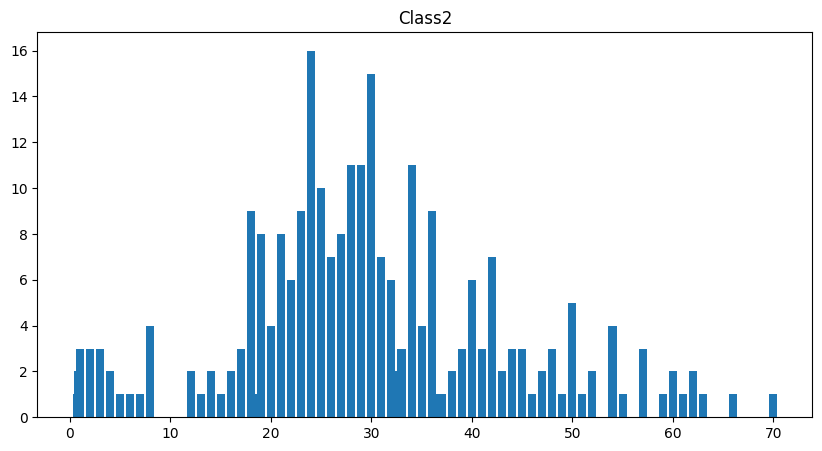

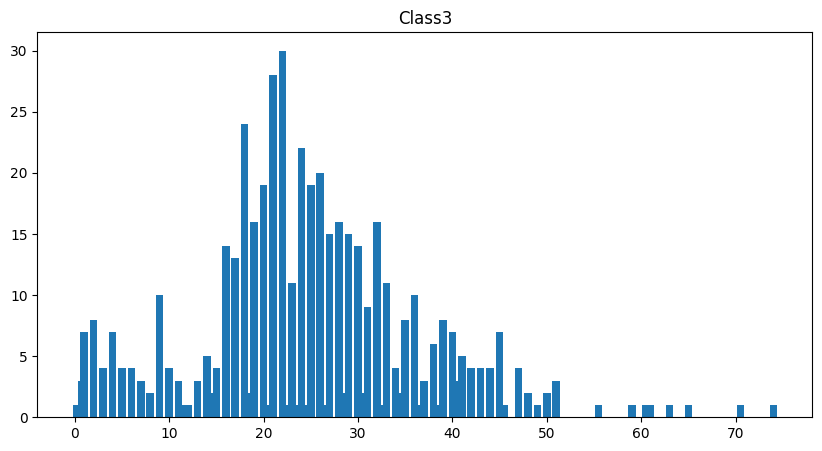

         Age
Pclass      
1       39.0
2       29.0
3       24.0


In [6]:
y = combind_pd["Age"].value_counts()
x = y.index.values

plt.figure(figsize = (10,5))
plt.bar(x,y)
plt.title("All ages")
plt.show()

class_age = combind_pd[['Pclass', 'Age']]

for i in range(1,4):
    plt.figure(figsize = (10,5))
    plt.title("Class"+str(i))
    y = class_age[class_age["Pclass"] == i]["Age"].value_counts()
    x = y.index.values
    plt.bar(x,y)
    plt.show()


medians = class_age.groupby('Pclass').median()
print(medians)

In [7]:
combind_pd['Age'] = combind_pd.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.median())
)
print(combind_pd['Age'].isnull().sum())  # должно быть 0

0


In [8]:
combind_pd['Fare'].fillna(combind_pd['Fare'].median(), inplace=True)

print(combind_pd['Fare'].isnull().sum())

0


C:\Users\nyuzi\AppData\Local\Temp\ipykernel_9956\98348569.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combind_pd['Fare'].fillna(combind_pd['Fare'].median(), inplace=True)


In [9]:
most_common_port = combind_pd['Embarked'].mode()[0]   # обычно 'S'
combind_pd['Embarked'].fillna(most_common_port, inplace=True)


C:\Users\nyuzi\AppData\Local\Temp\ipykernel_9956\2823480656.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combind_pd['Embarked'].fillna(most_common_port, inplace=True)


In [10]:
embarked_dummies = pd.get_dummies(combind_pd['Embarked'], prefix='Emb')
combind_pd = pd.concat([combind_pd, embarked_dummies], axis=1)
combind_pd.drop('Embarked', axis=1, inplace=True)

In [11]:
sex_dummies = pd.get_dummies(combind_pd['Sex'], prefix='Sex', drop_first=True)
combind_pd = pd.concat([combind_pd, sex_dummies], axis=1)
combind_pd.drop('Sex', axis=1, inplace=True)

In [12]:
# 1. Создаём бинарный признак: 1 — если каюта известна, 0 — если нет
combind_pd['HasCabin'] = combind_pd['Cabin'].notnull().astype(int)

# 2. Удаляем исходный столбец Cabin (без inplace, надёжное присваивание)
combind_pd = combind_pd.drop('Cabin', axis=1)

In [13]:
print(combind_pd[['PassengerId', 'HasCabin']].head(10))
print("Оставшиеся столбцы:", combind_pd.columns.tolist())
# Убедимся, что пропусков в HasCabin нет (должен быть 0)
print(combind_pd['HasCabin'].isnull().sum())

   PassengerId  HasCabin
0            1         0
1            2         1
2            3         0
3            4         1
4            5         0
5            6         0
6            7         1
7            8         0
8            9         0
9           10         0
Оставшиеся столбцы: ['PassengerId', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Emb_C', 'Emb_Q', 'Emb_S', 'Sex_male', 'HasCabin']
0


In [14]:
combind_pd['Title'] = combind_pd['Name'].str.extract(r',\s*([^\.]+)\.')

In [15]:
# Словарь замен
title_mapping = {
    'Mlle': 'Miss',
    'Mme': 'Mrs',
    'Ms': 'Miss',
    'Dr': 'Rare',
    'Rev': 'Rare',
    'Col': 'Rare',
    'Major': 'Rare',
    'Lady': 'Rare',
    'Sir': 'Rare',
    'Don': 'Rare',
    'Dona': 'Rare',
    'Jonkheer': 'Rare',
    'Countess': 'Rare',
    'Capt': 'Rare'
}

# Замена титулов
combind_pd['Title'] = combind_pd['Title'].replace(title_mapping)

# Проверяем результат
print(combind_pd['Title'].value_counts())

Title
Mr              757
Miss            264
Mrs             198
Master           61
Rare             28
the Countess      1
Name: count, dtype: int64


In [16]:
# Создаём dummy-переменные (например, Title_Mr, Title_Miss, Title_Mrs, Title_Rare)
title_dummies = pd.get_dummies(combind_pd['Title'], prefix='Title', drop_first=True)

# Добавляем их в DataFrame
combind_pd = pd.concat([combind_pd, title_dummies], axis=1)

# Удаляем исходные текстовые столбцы Title и Name (Name больше не нужен)
combind_pd = combind_pd.drop(['Name', 'Title'], axis=1)

In [17]:
combind_pd['FamilySize'] = combind_pd['SibSp'] + combind_pd['Parch'] + 1

In [18]:
combind_pd['IsAlone'] = (combind_pd['FamilySize'] == 1).astype(int)

# Удаление исходных столбцов
combind_pd = combind_pd.drop(['SibSp', 'Parch'], axis=1)

# Проверка
print(combind_pd[['FamilySize', 'IsAlone']].head())

   FamilySize  IsAlone
0           2        0
1           2        0
2           1        1
3           2        0
4           1        1


In [19]:
combind_pd.isnull().sum()

PassengerId           0
Pclass                0
Age                   0
Ticket                0
Fare                  0
Emb_C                 0
Emb_Q                 0
Emb_S                 0
Sex_male              0
HasCabin              0
Title_Miss            0
Title_Mr              0
Title_Mrs             0
Title_Rare            0
Title_the Countess    0
FamilySize            0
IsAlone               0
dtype: int64

In [20]:
# Разделение на трейн и тест
train_clean = combind_pd[combind_pd['PassengerId'].isin(train_idx)]
test_clean  = combind_pd[combind_pd['PassengerId'].isin(test_idx)]

# Отделяем признаки (убираем ID)
X_train = train_clean.drop('PassengerId', axis=1)
X_test  = test_clean.drop('PassengerId', axis=1)
X_train = X_train.drop('Ticket', axis=1)
X_test = X_test.drop('Ticket', axis=1)

# Целевая переменная (мы сохранили её в самом начале)
y = survived

# Контрольные отпечатки
print(f"X_train: {X_train.shape}, y: {y.shape}")
print(f"X_test: {X_test.shape}")
print(f"Пропусков в X_train: {X_train.isnull().sum().sum()}")
print(f"Пропусков в X_test: {X_test.isnull().sum().sum()}")
print(type(y))
print(y.dtype if hasattr(y, 'dtype') else 'не pandas')
print(y.head() if hasattr(y, 'head') else y[:5])
print(y.shape)

X_train: (891, 15), y: (891,)
X_test: (418, 15)
Пропусков в X_train: 0
Пропусков в X_test: 0
<class 'pandas.core.series.Series'>
int64
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64
(891,)


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

model = LogisticRegression(max_iter=1000)
scores = cross_val_score(model, X_train, y, cv=5, scoring='accuracy')
print(f"Средняя точность на кросс-валидации: {scores.mean():.4f}")


Средняя точность на кросс-валидации: 0.8227


In [27]:
from sklearn.linear_model import LogisticRegressionCV

# L1-регуляризация с подбором C через кросс-валидацию
l1_model = LogisticRegressionCV(penalty='l1', solver='saga', Cs=10, cv=5, max_iter=2000)
l1_model.fit(X_train, y)
# Посмотрим, какие признаки остались
coef = l1_model.coef_[0]
selected = pd.DataFrame({'feature': X_train.columns, 'coef': coef})
print(selected[selected['coef'] != 0].sort_values('coef'))

c:\Users\nyuzi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\nyuzi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\nyuzi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\nyuzi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\nyuzi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the 

       feature      coef
9     Title_Mr -1.117540
6     Sex_male -0.839729
13  FamilySize -0.185181
11  Title_Rare -0.046077
0       Pclass -0.004721
1          Age  0.000769
14     IsAlone  0.011001
2         Fare  0.011247
4        Emb_Q  0.024556
5        Emb_S  0.063683
3        Emb_C  0.271774
8   Title_Miss  0.465733
7     HasCabin  0.539528
10   Title_Mrs  0.550421
